In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# 1. Data loading and preparation
# Hint: Use transforms.ToTensor and Normalize
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
full_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_dataset, test_dataset = random_split(full_dataset, [50000, 10000])

# DataLoader: Remember, this is efficient for larger datasets
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 2. Model definition
class FashionClassifier(nn.Module):
    def __init__(self):
        super(FashionClassifier, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 128)  # Input layer to hidden layer
        self.fc2 = nn.Linear(128, 10)         # Hidden layer to output layer
        self.relu = nn.ReLU()                 # Activation function
        
        pass 

    def forward(self, x):
        # TODO: Define the flow of data through the layers
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = FashionClassifier()

# 3. Optimization and loss function
criterion = nn.CrossEntropyLoss()
# TODO: Choose an optimizer (Adam or SGD) and set the learning rate
optimizer = None 

# 4. Training loop
epochs = 5
loss_history = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        # TODO: Implement the training steps:
        # 1. Zero the gradients
        # 2. Forward pass
        # 3. Calculate loss
        # 4. Backward pass
        # 5. Optimizer step
        pass
    
    # avg_loss = ... (calculate average loss and append to list)
    # print(...)

# 5. Visualization
# plt.plot(...)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 1.05MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 9.51MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 33.5MB/s]



Aloitetaan opetus - Learning Rate: 0.01
Epoch 1/5 - Loss: 0.5557
Epoch 2/5 - Loss: 0.4604
Epoch 3/5 - Loss: 0.4367
Epoch 4/5 - Loss: 0.4230
Epoch 5/5 - Loss: 0.4072

Aloitetaan opetus - Learning Rate: 0.001
Epoch 1/5 - Loss: 0.5162
Epoch 2/5 - Loss: 0.3904
Epoch 3/5 - Loss: 0.3538
Epoch 4/5 - Loss: 0.3266
Epoch 5/5 - Loss: 0.3061

Aloitetaan opetus - Learning Rate: 0.0001
Epoch 1/5 - Loss: 0.7739
Epoch 2/5 - Loss: 0.5022
Epoch 3/5 - Loss: 0.4568
Epoch 4/5 - Loss: 0.4311
Epoch 5/5 - Loss: 0.4119


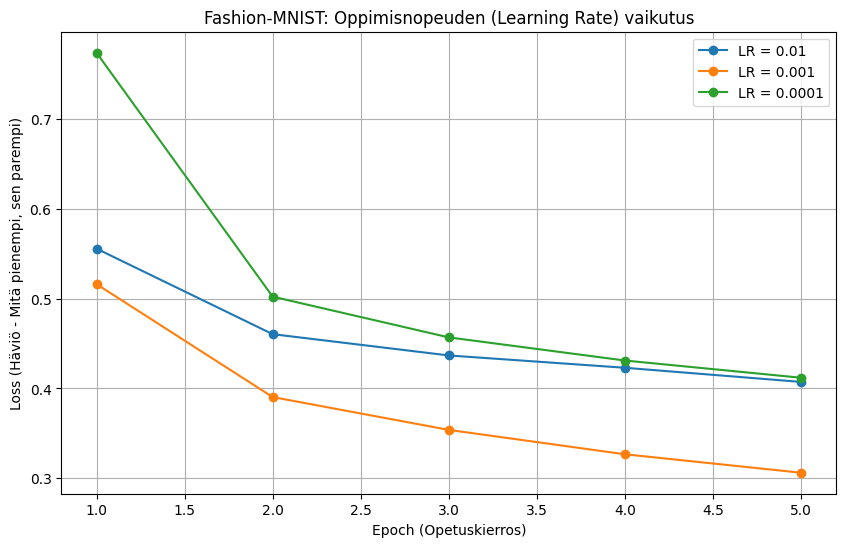

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# 1. Data loading and preparation
# Hint: Use transforms.ToTensor and Normalize
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
full_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_dataset, test_dataset = random_split(full_dataset, [50000, 10000])

# DataLoader: Remember, this is efficient for larger datasets
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 2. Model definition
class FashionClassifier(nn.Module):
    def __init__(self):
        super(FashionClassifier, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 128)  # Input layer to hidden layer
        self.fc2 = nn.Linear(128, 10)         # Hidden layer to output layer
        self.relu = nn.ReLU()                 # Activation function
        
        pass 

    def forward(self, x):
        # TODO: Define the flow of data through the layers
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x
    



learning_rates = [0.01, 0.001, 0.0001]
all_loss_histories = {} #tallenneteaan hävikki tänne

for lr in learning_rates:
    print(f"\n=========================================")
    print(f"Aloitetaan opetus - Learning Rate: {lr}")
    print(f"=========================================")

    model = FashionClassifier()  # Uusi malli jokaista oppimisnopeutta varten

    #3. Optimization and loss function
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)  # Käytetään Adam-optimointia

    #4. Training loop
    epochs = 5
    loss_history = [] #tallennetaan tämän kierroksen hävikki tähän listaan

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            optimizer.zero_grad()             # 1. Zero the gradients
            outputs = model(images)           # 2. Forward pass
            loss = criterion(outputs, labels) # 3. Calculate loss
            loss.backward()                   # 4. Backward pass
            optimizer.step()                  # 5. Optimizer step

            running_loss += loss.item()

        # calculate average loss and append to list
        avg_loss = running_loss / len(train_loader)
        loss_history.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")
        
    # Tallennetaan tämän kierroksen tulokset talteen dictionaryyn
    all_loss_histories[lr] = loss_history


# 5. Visualization
plt.figure(figsize=(10, 6))

# Piirretään kaikkien kolmen kokeilun viivat samaan kuvaajaan
for lr, history in all_loss_histories.items():
    plt.plot(range(1, epochs + 1), history, label=f'LR = {lr}', marker='o')

plt.xlabel('Epoch (Opetuskierros)')
plt.ylabel('Loss (Häviö - Mitä pienempi, sen parempi)')
plt.title('Fashion-MNIST: Oppimisnopeuden (Learning Rate) vaikutus')
plt.legend()
plt.grid(True)
plt.show()